# Physics-Informed Neural Networks (PINNs)

Traditional numerical methods — finite differences, finite elements, spectral methods — solve differential equations by discretising the domain and solving a large linear (or nonlinear) system. They are powerful but tied to a fixed grid and require re-solving from scratch whenever parameters change.

**Physics-Informed Neural Networks (PINNs)** take a different route: a neural network $u_\theta(x)$ is trained so that it simultaneously:
1. satisfies the **governing differential equation** at a set of collocation points, and
2. satisfies the **boundary (or initial) conditions** at the domain boundaries.

No labelled solution data is required — the physics *is* the training signal. The key enabler is **automatic differentiation**: PyTorch can compute exact derivatives of the network output with respect to its inputs, so the PDE residual can be evaluated and minimised directly.

In this notebook we apply a PINN to the simple **1-D Poisson equation**:

$$\frac{d^2 u}{dx^2} = \sin(\pi x), \qquad x \in [0,1], \quad u(0) = u(1) = 0$$

The exact solution is $u(x) = -\dfrac{1}{\pi^2}\sin(\pi x)$, which lets us validate the network's accuracy throughout training.

## 1. Background: PINNs and Automatic Differentiation

### Problem statement

We want to find $u : [0,1] \to \mathbb{R}$ satisfying the boundary value problem (BVP):

$$\mathcal{N}[u](x) := u_{xx}(x) - f(x) = 0, \quad f(x) = \sin(\pi x)$$

with Dirichlet boundary conditions $u(0) = 0$, $u(1) = 0$.

### PINN approach

We parameterise the solution as $u_\theta(x)$ — a fully-connected neural network. Training minimises the **composite loss**:

$$\mathcal{L}(\theta) = \underbrace{\frac{1}{N}\sum_{i=1}^{N} \left(\frac{d^2 u_\theta}{dx^2}(x_i) - f(x_i)\right)^2}_{\mathcal{L}_{\text{PDE}}} + \underbrace{u_\theta(0)^2 + u_\theta(1)^2}_{\mathcal{L}_{\text{BC}}}$$

The points $\{x_i\}_{i=1}^N$ are called **collocation points** — they are the locations where the PDE is enforced.

### Automatic differentiation in PyTorch

PyTorch builds a **computational graph** during the forward pass. Calling `torch.autograd.grad` then traverses this graph backwards to compute exact derivatives — not finite-difference approximations. To differentiate with respect to an input tensor $x$ (rather than network weights), we set `x.requires_grad_(True)` before the forward pass and request gradients via:

```python
u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),  create_graph=True)[0]
u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x))[0]
```

`create_graph=True` keeps the graph alive for the second differentiation. This is the PyTorch equivalent of TensorFlow's nested `GradientTape`.

## 2. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Collocation Points

The collocation points $\{x_i\}$ are the locations inside the domain where the PDE residual will be computed and minimised. We use $N = 100$ uniformly spaced points in $[0, 1]$.

Two things are critical:
- The tensor must be on the correct `device` so that all subsequent computations stay on the same hardware.
- `requires_grad_(True)` tells PyTorch to track operations involving `x` in the computational graph, which is needed to differentiate the network output *with respect to the input* $x$ — not just with respect to the weights.

In [2]:
N = 100
x = torch.linspace(0, 1, N, dtype=torch.float32).view(-1, 1).to(device)
x.requires_grad_(True)

# Exact solution for validation
x_np    = np.linspace(0, 1, 200).reshape(-1, 1)
u_exact = -1.0 / np.pi**2 * np.sin(np.pi * x_np)

print(f"Collocation points shape : {x.shape}")
print(f"requires_grad            : {x.requires_grad}")

Collocation points shape : torch.Size([100, 1])
requires_grad            : True


## 4. Network Architecture

The network maps a scalar $x \in [0,1]$ to a scalar $u_\theta(x) \in \mathbb{R}$. We use three hidden layers of width 20 with $\tanh$ activations.

**Why $\tanh$?**  
PINNs need smooth activations so that higher-order derivatives exist and are well-behaved. $\tanh$ is infinitely differentiable and saturates gracefully, which helps with the second derivative $u_{xx}$ computed during loss evaluation. ReLU activations, whose second derivative is zero almost everywhere, are unsuitable for this task.

| Layer | Type | In | Out | Activation |
|-------|------|----|-----|------------|
| 1 | Linear | 1 | 20 | tanh |
| 2 | Linear | 20 | 20 | tanh |
| 3 | Linear | 20 | 20 | tanh |
| 4 | Linear | 20 | 1 | — (linear) |

In [3]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),  nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)


model = PINN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {n_params:,}")
print(model)

Trainable parameters: 901
PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)


## 5. Loss Functions

### PDE residual loss

We compute the second derivative of the network output with respect to the input using two chained calls to `torch.autograd.grad`. The first call returns $u_x = \partial u_\theta / \partial x$; the second returns $u_{xx} = \partial^2 u_\theta / \partial x^2$.

The PDE loss is then the mean squared residual:

$$\mathcal{L}_{\text{PDE}} = \frac{1}{N}\sum_{i=1}^{N}\left(u_{xx}(x_i) - \sin(\pi x_i)\right)^2$$

### Boundary condition loss

We evaluate the network at the two boundary points and penalise any deviation from zero:

$$\mathcal{L}_{\text{BC}} = u_\theta(0)^2 + u_\theta(1)^2$$

Note: `create_graph=True` in the first `autograd.grad` call is essential — it keeps the computation graph alive so that the second derivative can be computed, and so that gradients of $u_{xx}$ with respect to the weights $\theta$ are available for the optimiser.

In [4]:
def pde_loss(model, x):
    u    = model(x)
    u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    residual = u_xx - torch.sin(np.pi * x)
    return torch.mean(residual ** 2)


def boundary_loss(model):
    x0 = torch.tensor([[0.0]], dtype=torch.float32, device=device)
    x1 = torch.tensor([[1.0]], dtype=torch.float32, device=device)
    return model(x0) ** 2 + model(x1) ** 2


def total_loss(model, x):
    return pde_loss(model, x) + boundary_loss(model)

## 6. Training

We train with the **Adam** optimiser for up to 3 000 epochs. Adam adapts the learning rate per parameter, which tends to converge faster than vanilla SGD on PINN problems.

The training loop is straightforward:
1. Zero the gradients stored in the optimiser.
2. Evaluate the total loss (PDE + BC).
3. Backpropagate to compute gradients of the loss with respect to all network weights.
4. Take an optimiser step to update the weights.

We log the loss every 300 epochs and store the history for the learning curve plot.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs    = 3000
loss_history = []

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    loss = total_loss(model, x)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 300 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6e}")

print("\nTraining complete.")

Epoch   300 | Loss: 5.984479e-04
Epoch   600 | Loss: 4.382797e-04
Epoch   900 | Loss: 2.440187e-04
Epoch  1200 | Loss: 6.752213e-05
Epoch  1500 | Loss: 2.118978e-05
Epoch  1800 | Loss: 1.747098e-05
Epoch  2100 | Loss: 1.537773e-05
Epoch  2400 | Loss: 1.373487e-05
Epoch  2700 | Loss: 1.235009e-05
Epoch  3000 | Loss: 1.103826e-05

Training complete.


## 7. Learning Curve

Plotting the training loss on a **log scale** reveals three characteristic phases common to PINN training:

1. **Fast initial descent** — the network quickly learns the rough shape of the solution.
2. **Slower refinement** — the network adjusts fine-scale details to satisfy the PDE more precisely.
3. **Plateau** — the residual reaches the level of floating-point noise or the network's expressive capacity.

A well-trained PINN should reach a loss of $\mathcal{O}(10^{-5})$ or lower for this simple problem.

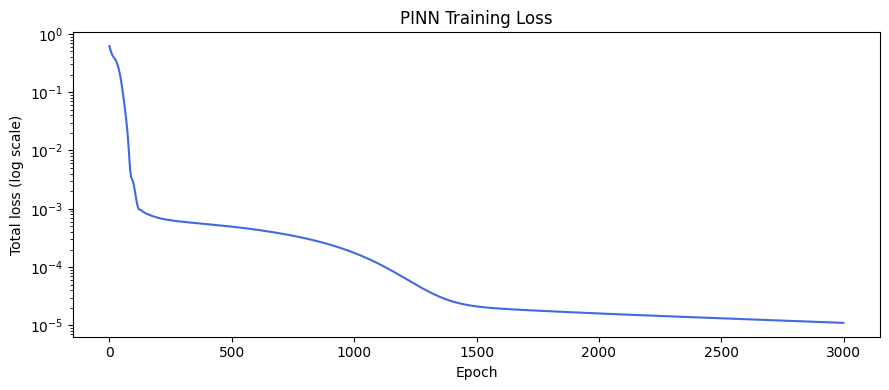

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(loss_history, color='royalblue')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Total loss (log scale)')
plt.title('PINN Training Loss')
plt.tight_layout()
plt.show()

## 8. Solution Comparison

We evaluate the trained network on a fine grid and compare it to the analytical solution $u(x) = -\frac{1}{\pi^2}\sin(\pi x)$. A good PINN solution should be visually indistinguishable from the exact curve.

We also plot the **pointwise absolute error** $|u_\theta(x) - u(x)|$ to quantify where the approximation is least accurate — typically near the boundaries, where the BC loss and PDE loss pull in slightly different directions.

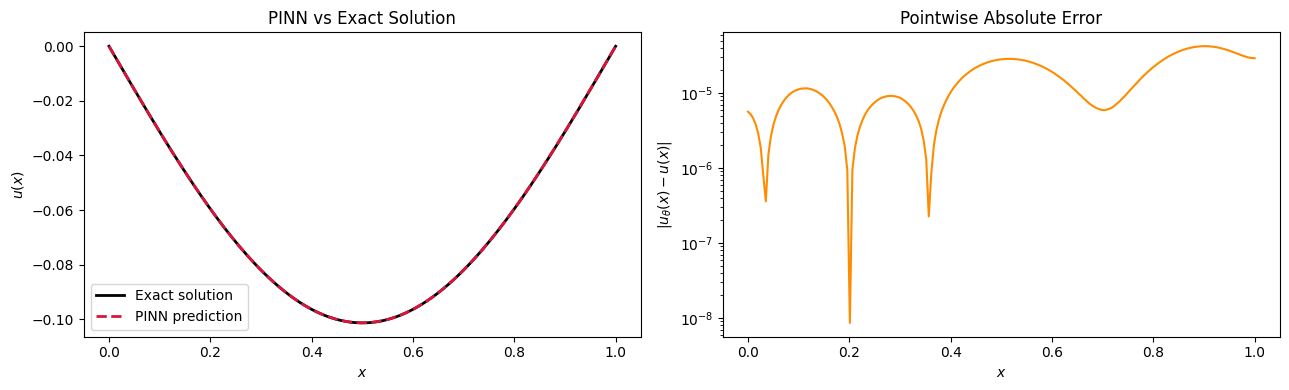

Max absolute error : 4.21e-05
Mean absolute error: 1.65e-05


In [7]:
model.eval()
with torch.no_grad():
    x_plot  = torch.linspace(0, 1, 200, dtype=torch.float32).view(-1, 1).to(device)
    u_pred  = model(x_plot).cpu().numpy()

x_plot_np = x_plot.cpu().numpy()
error     = np.abs(u_pred - u_exact)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_plot_np, u_exact, label='Exact solution',  color='black', linewidth=2)
axes[0].plot(x_plot_np, u_pred,  label='PINN prediction', color='crimson', linestyle='--', linewidth=2)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$u(x)$')
axes[0].set_title('PINN vs Exact Solution')
axes[0].legend()

axes[1].plot(x_plot_np, error, color='darkorange')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$|u_\\theta(x) - u(x)|$')
axes[1].set_title('Pointwise Absolute Error')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Max absolute error : {error.max():.2e}")
print(f"Mean absolute error: {error.mean():.2e}")

## 9. Effect of Collocation Point Density

How many collocation points do we need? More points provide a better approximation of the integral over the domain but increase the cost per epoch. We compare four densities to illustrate the trade-off.

For each density we train a fresh network for a fixed number of epochs and record the final maximum error against the exact solution.

N =   10 | max error = 4.76e-05
N =   25 | max error = 2.22e-05
N =   50 | max error = 1.64e-05
N =  100 | max error = 2.14e-05


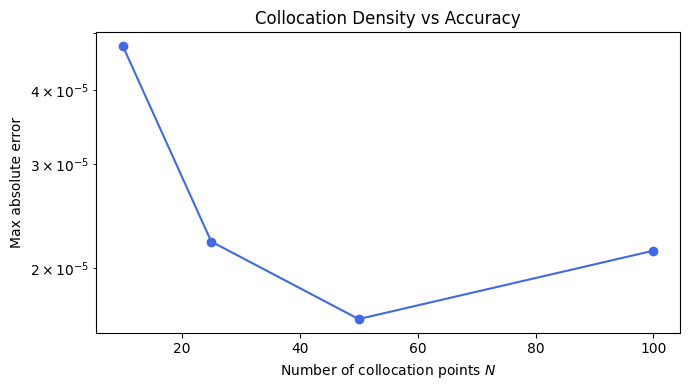

In [8]:
point_counts = [10, 25, 50, 100]
results      = {}

for n in point_counts:
    xc = torch.linspace(0, 1, n, dtype=torch.float32).view(-1, 1).to(device)
    xc.requires_grad_(True)

    net  = PINN().to(device)
    opt  = torch.optim.Adam(net.parameters(), lr=1e-3)

    for _ in range(3000):
        opt.zero_grad()
        loss = total_loss(net, xc)
        loss.backward()
        opt.step()

    net.eval()
    with torch.no_grad():
        x_eval = torch.linspace(0, 1, 200, dtype=torch.float32).view(-1, 1).to(device)
        u_p    = net(x_eval).cpu().numpy()
    err = np.abs(u_p - u_exact).max()
    results[n] = err
    print(f"N = {n:4d} | max error = {err:.2e}")

plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), list(results.values()), 'o-', color='royalblue')
plt.xlabel('Number of collocation points $N$')
plt.ylabel('Max absolute error')
plt.yscale('log')
plt.title('Collocation Density vs Accuracy')
plt.tight_layout()
plt.show()

## 10. Summary and Key Takeaways

| | |
|---|---|
| **Problem** | 1-D Poisson BVP: $u_{xx} = \sin(\pi x)$, $u(0)=u(1)=0$ |
| **Exact solution** | $u(x) = -\frac{1}{\pi^2}\sin(\pi x)$ |
| **Architecture** | Linear(1→20) + Tanh × 3 + Linear(20→1) |
| **Loss** | $\mathcal{L}_{\text{PDE}}$ (MSE residual at $N$ collocation points) + $\mathcal{L}_{\text{BC}}$ (squared boundary values) |
| **Optimiser** | Adam, lr = $10^{-3}$, 3 000 epochs |
| **Key tool** | `torch.autograd.grad` with `create_graph=True` for exact $u_{xx}$ |

### Key takeaways

- **No labelled data needed**: the PDE and boundary conditions *are* the training signal. PINNs are a form of **unsupervised physics-constrained learning**.
- **Automatic differentiation is exact**: unlike finite-difference-based residuals, `autograd` computes the true derivative of the network output, so the loss faithfully reflects the PDE residual.
- **$\tanh$ over ReLU**: smooth activations are mandatory for PINNs that involve second (or higher) derivatives, since ReLU's second derivative is zero almost everywhere.
- **`create_graph=True` is essential**: without it PyTorch discards the computation graph after the first derivative, making the second derivative (and its gradient w.r.t. $\theta$) unavailable.
- **Scalability**: the same framework extends to higher-dimensional PDEs (Navier–Stokes, heat equation, wave equation) simply by changing the loss function — no meshing required.